#AAI-511 Group 6 Final Project

Juan Norena  
Evelin Bustamante  
Daniel Sims

## 1. Data Collection & Setup

In [6]:
!pip install pretty_midi pypianoroll -q
print("Libraries installed successfully.")

Libraries installed successfully.


### Downloading the Dataset

In [7]:
!pip install kagglehub -q
import kagglehub
import shutil
import os

DATA_DIR = 'music_data'

# Check if directory exists and is not empty
# if os.path.exists(DATA_DIR) and len(os.listdir(DATA_DIR)) > 0:
#     print(f"'{DATA_DIR}' already exists and contains files. Skipping download.")
# else:

print("Downloading dataset via kagglehub...")
# Download latest version
path = kagglehub.dataset_download("blanderbuss/midi-classic-music")
print("Path to downloaded files:", path)

# Move files to our expected 'music_data' directory for the rest of the notebook
os.makedirs(DATA_DIR, exist_ok=True)
for item in os.listdir(path):
    s = os.path.join(path, item)
    d = os.path.join(DATA_DIR, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print(f"Dataset successfully copied to /{DATA_DIR}/")

Using Colab cache for faster access to the 'midi-classic-music' dataset.
Path to downloaded files: /kaggle/input/midi-classic-music
Dataset successfully copied to /music_data/


## 2. Data Pre-processing and Feature Extraction

In [8]:
import glob
import pretty_midi
import pandas as pd
import numpy as np
import collections
from tqdm import tqdm

# Define our target composers
TARGET_COMPOSERS = ['bach', 'beethoven', 'chopin', 'mozart']
DATA_PATH = 'music_data/'

def get_midi_files(data_path, target_composers):
    """
    Scans the directory for MIDI files matching the target composers.
    Assumes file names or folder names contain the composer's name.
    """
    all_midi_files = glob.glob(os.path.join(data_path, '**/*.mid*'), recursive=True)
    filtered_files = []

    for file in all_midi_files:
        file_lower = file.lower()
        for composer in target_composers:
            if composer in file_lower:
                filtered_files.append({'path': file, 'composer': composer})
                break # Move to next file once composer is found

    return pd.DataFrame(filtered_files)

df_files = get_midi_files(DATA_PATH, TARGET_COMPOSERS)
print(f"Found {len(df_files)} MIDI files matching target composers.")
if not df_files.empty:
    display(df_files['composer'].value_counts())

Found 1559 MIDI files matching target composers.


,count
composer,
bach,950
mozart,259
beethoven,212
chopin,138


### Extracting Notes from MIDI

In [12]:
def midi_to_notes(midi_file: str) -> pd.DataFrame:
    """
    Extracts notes from a MIDI file and returns a DataFrame of note attributes.
    """
    try:
        pm = pretty_midi.PrettyMIDI(midi_file)
    except Exception as e:
        # Some MIDI files might be corrupted or unreadable
        # print(f"Error reading {midi_file}: {e}")
        return None

    instrument = pm.instruments[0] # Usually the main instrument (e.g., Piano)
    notes = collections.defaultdict(list)

    # Sort the notes by start time
    sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
    prev_start = sorted_notes[0].start if sorted_notes else 0

    for note in sorted_notes:
        start = note.start
        end = note.end
        notes['pitch'].append(note.pitch)
        notes['velocity'].append(note.velocity) # Added velocity feature
        notes['start'].append(start)
        notes['end'].append(end)
        notes['step'].append(start - prev_start)
        notes['duration'].append(end - start)
        prev_start = start

    return pd.DataFrame({name: np.array(value) for name, value in notes.items()})

if not df_files.empty:
    sample_file = df_files.iloc[0]['path']
    sample_notes = midi_to_notes(sample_file)
    if sample_notes is not None:
        display(sample_notes.head())

,pitch,velocity,start,end,step,duration
0,60,76,0.000000,0.107143,0.000000,0.107143
1,62,76,0.214286,0.321428,0.214286,0.107143
2,64,76,0.428571,0.482142,0.214286,0.053571
3,64,76,0.642857,0.749999,0.214286,0.107143
4,65,76,0.857142,0.964285,0.214286,0.107143


## 3. Data Preparation for Model Training

Once notes are extracted, they need to be normalized and chunked into fixed-length sequences (e.g., sequences of 50 or 100 notes) so they can be fed into an LSTM or CNN. The code below provides the skeleton for building these sequence datasets.

In [13]:
def create_sequences(df_files, seq_length=100):
    """
    Processes all MIDI files to create numerical sequences and labels.
    """
    all_sequences = []
    all_labels = []

    # Mapping composers to integers
    label_map = {comp: idx for idx, comp in enumerate(TARGET_COMPOSERS)}

    print("Processing MIDI files into sequences...")
    for idx, row in tqdm(df_files.iterrows(), total=len(df_files)):
        notes_df = midi_to_notes(row['path'])
        if notes_df is None or len(notes_df) < seq_length:
            continue

        # Extract relevant features including the new velocity feature
        features = notes_df[['pitch', 'step', 'duration', 'velocity']].values
        label = label_map[row['composer']]

        # Create overlapping sequences
        for i in range(0, len(features) - seq_length, seq_length):
            seq = features[i:i + seq_length]
            all_sequences.append(seq)
            all_labels.append(label)

    return np.array(all_sequences), np.array(all_labels)

X, y = create_sequences(df_files, seq_length=100)
print(f"\nCreated {X.shape[0]} sequences of length {X.shape[1]}.")
print(f"Feature shape per note: {X.shape[2]} (pitch, step, duration, velocity)")

Processing MIDI files into sequences...


  0%|          | 4/1559 [00:00<01:33, 16.65it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
  1%|          | 12/1559 [00:01<04:23,  5.88it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or 


Created 11241 sequences of length 100.
Feature shape per note: 4 (pitch, step, duration, velocity)


## 4. Exploratory Data Analysis (EDA)

/tmp/ipykernel_3480/384873243.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_files, x='composer', order=TARGET_COMPOSERS, palette='viridis')


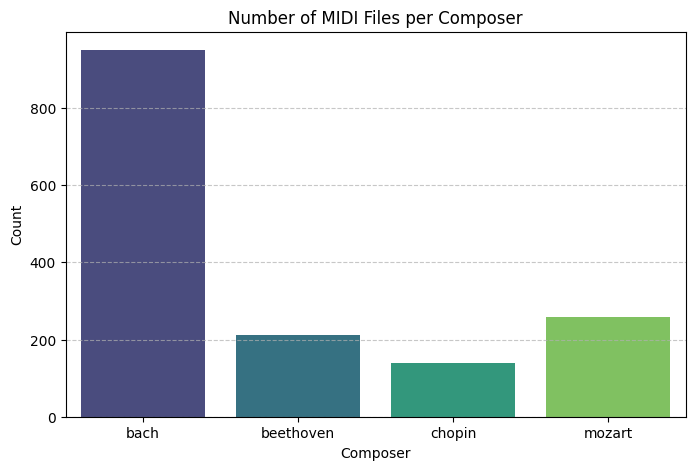

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Composer Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_files, x='composer', order=TARGET_COMPOSERS, palette='viridis')
plt.title('Number of MIDI Files per Composer')
plt.xlabel('Composer')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

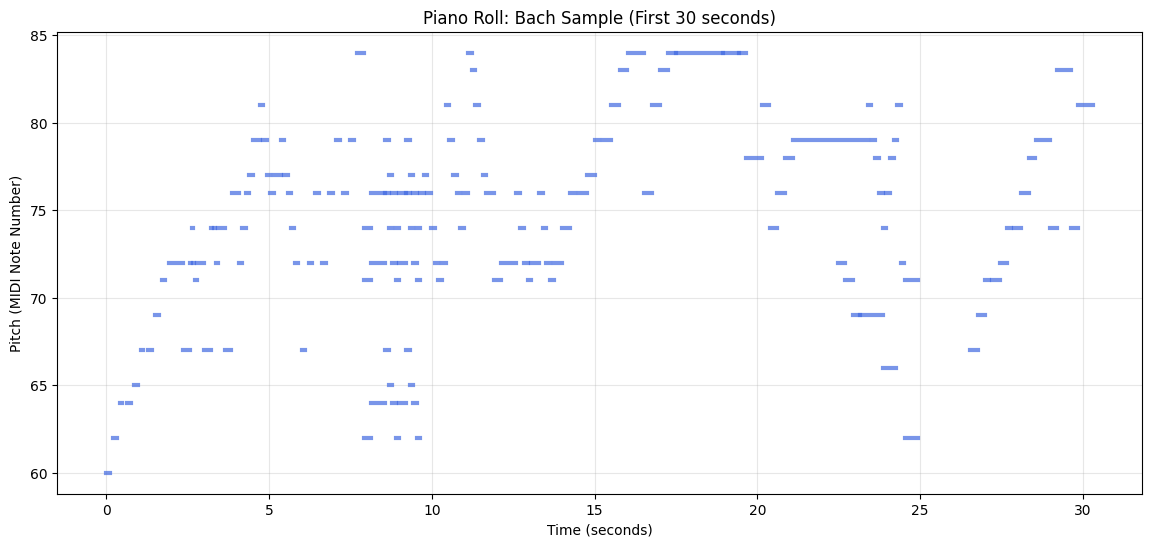

In [15]:
def plot_piano_roll(notes_df, title="Piano Roll", end_time=None):
    """
    Plots a piano roll (pitch over time) for a given DataFrame of notes.
    """
    plt.figure(figsize=(14, 6))

    if end_time:
        notes_df = notes_df[notes_df['start'] < end_time]

    for _, note in notes_df.iterrows():

        plt.plot([note['start'], note['end']], [note['pitch'], note['pitch']],
                 linewidth=3, color='royalblue', alpha=0.7)

    plt.title(title)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Pitch (MIDI Note Number)')
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot the first 30 seconds of the sample file
if not df_files.empty and sample_notes is not None:
    composer_name = df_files.iloc[0]['composer'].title()
    plot_piano_roll(sample_notes, title=f"Piano Roll: {composer_name} Sample (First 30 seconds)", end_time=30.0)

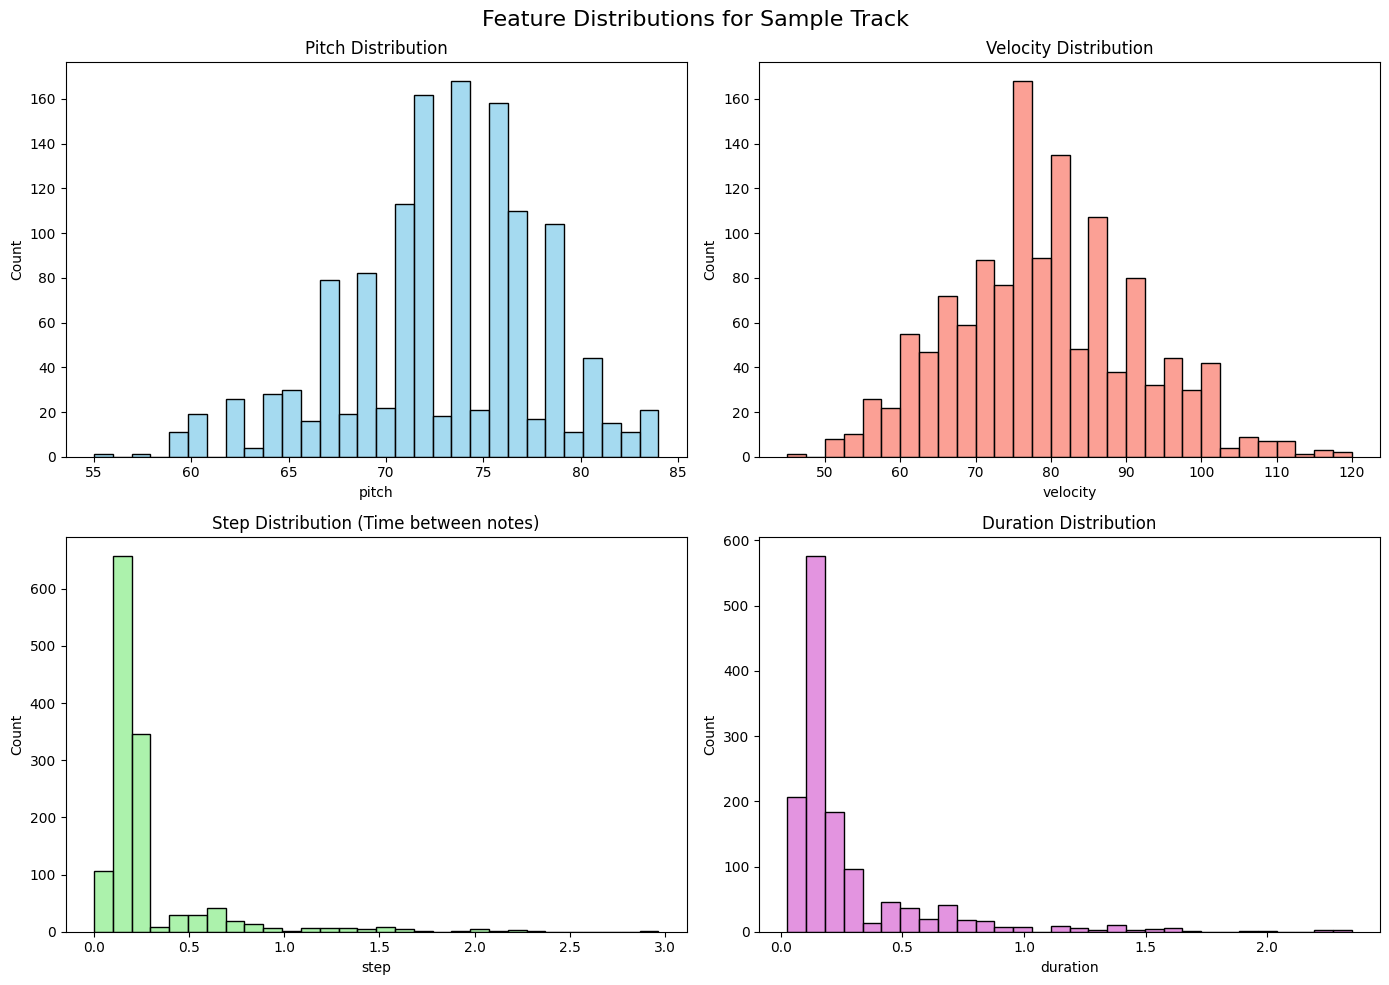

In [16]:
# Feature Distributions
if not df_files.empty and sample_notes is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Feature Distributions for Sample Track', fontsize=16)

    sns.histplot(sample_notes['pitch'], bins=30, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Pitch Distribution')

    sns.histplot(sample_notes['velocity'], bins=30, ax=axes[0, 1], color='salmon')
    axes[0, 1].set_title('Velocity Distribution')

    sns.histplot(sample_notes['step'], bins=30, ax=axes[1, 0], color='lightgreen')
    axes[1, 0].set_title('Step Distribution (Time between notes)')

    sns.histplot(sample_notes['duration'], bins=30, ax=axes[1, 1], color='orchid')
    axes[1, 1].set_title('Duration Distribution')

    plt.tight_layout()
    plt.show()